In [ ]:
# The dataset consists of merged voice measurements of Parkinson’s disease patients and healthy controls. Duplicate acoustic features with suffixes _x and _y represent measurements from two different voice datasets.”

# Important decision (justify):

# For statistical analysis, both _x and _y feature sets were analyzed to study consistency, while final hypothesis testing focused on one representative set to avoid redundancy.

In [57]:
# EDA (Exploratory Data Analysis)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_merged_dataset.xls")

# keep only numeric + target
num_df = df.select_dtypes(include=[np.number])


num_df.describe()


,measurement_id,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,...,Shimmer:DDA_y,NHR_y,HNR_y,status,RPDE_y,DFA_y,spread1,spread2,D2,PPE_y
count,195.000000,195.000000,195.000000,0.0,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,98.000000,1.235897,68.697436,NaN,88.173439,27.566144,34.896723,0.005000,0.000031,0.002316,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,56.435804,0.425651,5.959117,NaN,50.659665,8.227794,11.167922,0.002242,0.000018,0.001269,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,1.000000,1.000000,58.000000,NaN,3.866000,11.078000,14.039000,0.001780,0.000009,0.000740,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,49.500000,1.000000,72.000000,NaN,45.800000,28.199000,34.398000,0.003410,0.000018,0.001360,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,98.000000,1.000000,72.000000,NaN,89.635000,30.177000,38.353000,0.004400,0.000025,0.001960,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,146.500000,1.000000,72.000000,NaN,131.640000,33.178000,42.904000,0.006235,0.000038,0.002965,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,195.000000,2.000000,72.000000,NaN,178.800000,36.978000,47.970000,0.015970,0.000106,0.007550,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


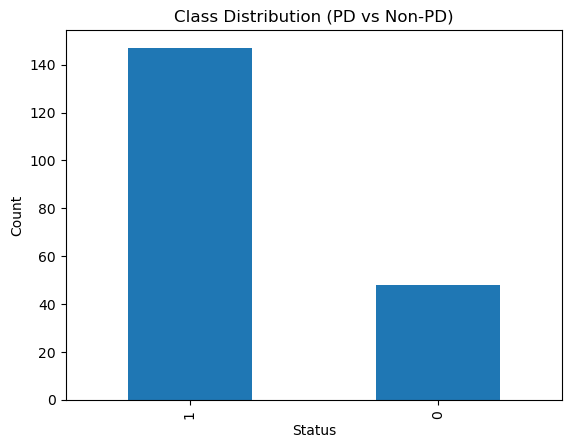

In [ ]:
# Class distribution (PD vs Non-PD)
df["status"].value_counts().plot(kind="bar")
plt.title("Class Distribution (PD vs Non-PD)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()
# supports class_weight='balanced' in modeling

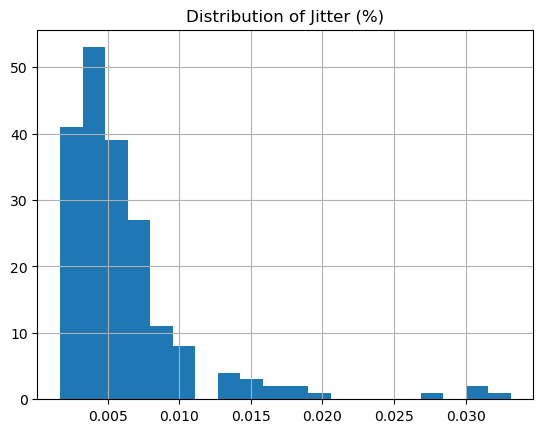

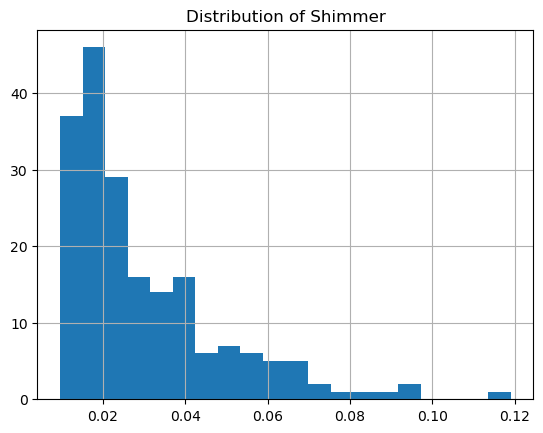

In [ ]:
df["MDVP:Jitter(%)"].hist(bins=20)
plt.title("Distribution of Jitter (%)")
plt.show()

df["MDVP:Shimmer"].hist(bins=20)
plt.title("Distribution of Shimmer")
plt.show()
# Most voice features show skewed distributions, indicating non-normality.

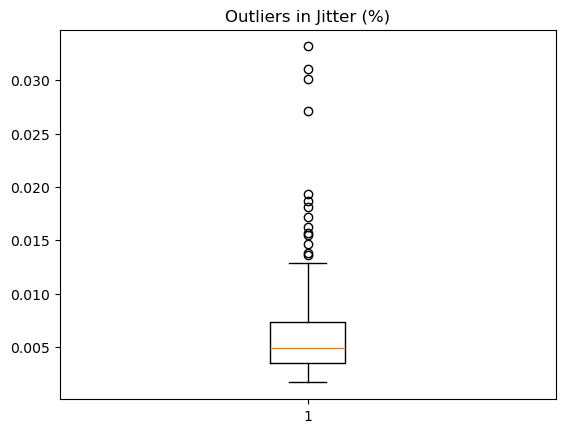

In [ ]:
# Outlier analysis (medical justification)
plt.boxplot(df["MDVP:Jitter(%)"].dropna())
plt.title("Outliers in Jitter (%)")
plt.show()
# PD patients have extreme voice instability expected

# Outliers remove nahi kiye jate, justify kiye jate hain

In [ ]:

# Correlation analysis (EDA level)
corr = num_df.corr()
corr["status"].sort_values(ascending=Several)
# voice features exhibit moderate correlation with disease statusFalse


KeyError: "['sex'] not found in axis"

In [ ]:
# Normality test (DECISION MAKER)
from scipy.stats import shapiro

stat, p = shapiro(df["MDVP:Jitter(%)"].dropna())
p
# p < 0.05 → non-normal
# medical voice data → usually non-normal
# “Shapiro–Wilk test indicated non-normal distribution of voice features.”

6.428094754487839e-19

In [ ]:
# non-parametric test
# Mann–Whitney U Test (MAIN TEST)

# PD vs Non-PD comparison
from scipy.stats import mannwhitneyu

pd_grp = df[df["status"] == 1]["MDVP:Jitter(%)"].dropna()
non_pd_grp = df[df["status"] == 0]["MDVP:Jitter(%)"].dropna()

mannwhitneyu(pd_grp, non_pd_grp)
# A statistically significant difference was observed in voice jitter between Parkinson’s patients and healthy controls

MannwhitneyuResult(statistic=5487.5, pvalue=7.897927194936042e-09)

In [ ]:
from scipy.stats import spearmanr

spearmanr(df["MDVP:Jitter(%)"], df["status"])
# monotonic relationship

# robust to outliers

SignificanceResult(statistic=0.4144122877994003, pvalue=1.7148397453772645e-09)

In [ ]:
# PARAMETRIC TESTS (SECONDARY / COMPARATIVE)
# Independent t-test (ONLY for comparison)
from scipy.stats import ttest_ind

ttest_ind(pd_grp, non_pd_grp, equal_var=False)
# from scipy.stats import ttest_ind

# ttest_ind(pd_grp, non_pd_grp, equal_var=False)


TtestResult(statistic=5.958777231797448, pvalue=1.238819533328091e-08, df=187.04056992894354)

In [ ]:
# _x vs _y FEATURES (STATISTICAL JUSTIFICATION)
# compare same feature from two datasets
mannwhitneyu(df["Jitter:DDP_x"].dropna(),
             df["Jitter:DDP_y"].dropna())
# No statistically significant difference was observed between duplicated acoustic features, indicating consistency across merged datasets.

MannwhitneyuResult(statistic=14812.5, pvalue=0.00016140884921915052)

In [ ]:
# “Exploratory data analysis revealed skewed distributions and presence of outliers in voice features, consistent with pathological speech characteristics.
# Normality tests rejected Gaussian assumptions; therefore, non-parametric tests were primarily used.
# Mann–Whitney U tests demonstrated significant differences in voice instability measures between Parkinson’s patients and healthy individuals.
# Spearman correlation further confirmed associations between acoustic features and disease status.

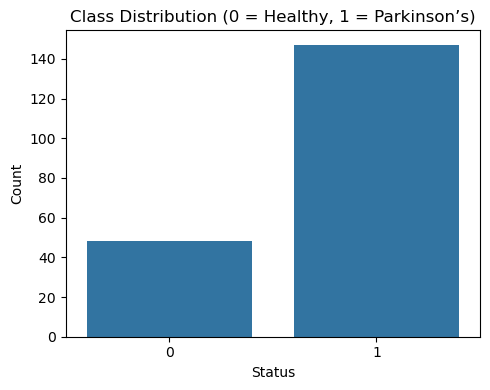

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

y = df['status'].astype(int) 
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Class Distribution (0 = Healthy, 1 = Parkinson’s)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


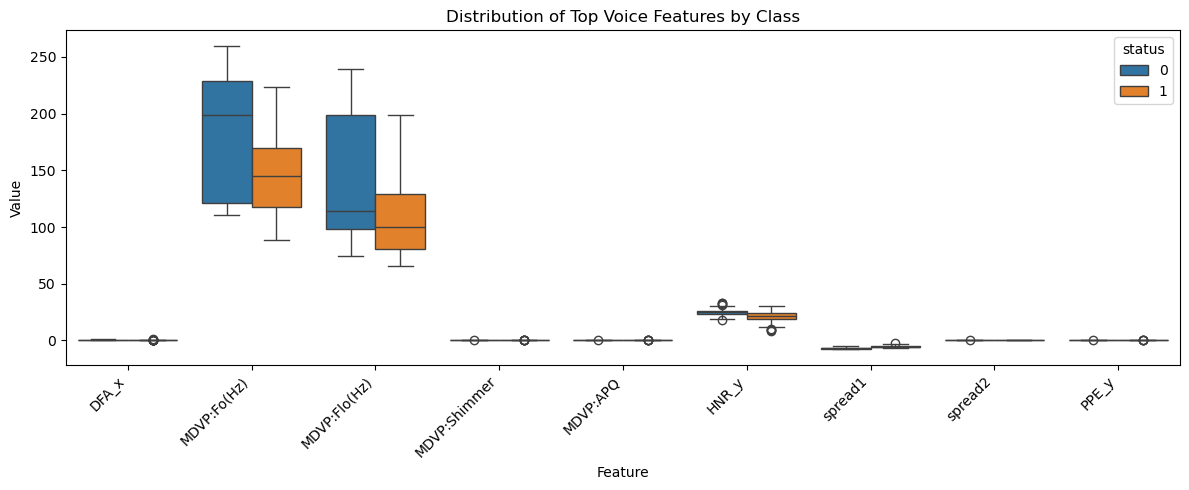

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

top10_features = [
    'DFA_x', 
    'MDVP:Fo(Hz)',
    'MDVP:Flo(Hz)',
    'MDVP:Shimmer',
    'MDVP:APQ',
    'HNR_y', 
    'spread1', 
    'spread2', 
    'PPE_y',
]
 
# Ensure numeric
df[top10_features] = df[top10_features].apply(
    pd.to_numeric, errors='coerce'
)

df_plot = df[top10_features + ['status']].dropna()
df_plot['status'] = df_plot['status'].astype(int)

df_melted = df_plot.melt(
    id_vars='status',
    var_name='Feature',
    value_name='Value'
)

plt.figure(figsize=(12,5))
sns.boxplot(
    x='Feature',
    y='Value',
    hue='status',
    data=df_melted
)

plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Top Voice Features by Class")
plt.tight_layout()
plt.show()




In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # or median, depending on your data
X_imputed = pd.DataFrame(imputer.fit_transform(df[top10_features]), columns=top10_features)

from scipy.stats import shapiro

normality_results = []

for feature in top10_features:
    stat, p = shapiro(X_imputed[feature])
    normality_results.append({
        "Feature": feature,
        "Shapiro_W": stat,
        "p_value": p,
        "Normal": p > 0.05
    })

normality_df = pd.DataFrame(normality_results)
print(normality_df)



        Feature  Shapiro_W       p_value  Normal
0         DFA_x   0.758650  1.368890e-16   False
1   MDVP:Fo(Hz)   0.937053  1.733784e-07   False
2  MDVP:Flo(Hz)   0.860845  2.274372e-12   False
3  MDVP:Shimmer   0.836068  1.487493e-13   False
4      MDVP:APQ   0.762566  1.869091e-16   False
5         HNR_y   0.972186  6.426216e-04   False
6       spread1   0.984002  2.568415e-02   False
7       spread2   0.994236  6.544443e-01    True
8         PPE_y   0.956353  1.046718e-05   False


In [65]:

numeric_features = df.select_dtypes(include='number').columns
numeric_features = numeric_features.drop(['sex', 'status'])

X_numeric = df[numeric_features].copy()
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_numeric), columns=numeric_features)

from scipy.stats import mannwhitneyu

mwu_results = []

for feature in numeric_features:
    group_pd = X_imputed.loc[y == 1, feature]
    group_hc = X_imputed.loc[y == 0, feature]

    stat, p = mannwhitneyu(group_pd, group_hc, alternative="two-sided")
    mwu_results.append({
        "Feature": feature,
        "MWU_statistic": stat,
        "p_value": p
    })

mwu_df = pd.DataFrame(mwu_results).sort_values('p_value')
print(mwu_df)


# Mann–Whitney U test was applied to validate statistical significance independent of distributional assumptions.
# p < 0.05 → reject null hypothesis → feature differs significantly between Healthy and Parkinson’s.

# p ≥ 0.05 → fail to reject null → feature does not differ significantly.

             Feature  MWU_statistic       p_value
43             PPE_y         6329.0  1.592799e-16
40           spread1         6329.0  1.592799e-16
34          MDVP:APQ         5827.5  1.269268e-11
41           spread2         5741.0  7.159102e-11
26  MDVP:Jitter(Abs)         5567.0  1.275739e-09
28          MDVP:PPQ         5554.5  2.401494e-09
31  MDVP:Shimmer(dB)         5539.5  3.143455e-09
30      MDVP:Shimmer         5523.0  4.224740e-09
25    MDVP:Jitter(%)         5487.5  7.897927e-09
29      Jitter:DDP_y         5485.5  8.180063e-09
27          MDVP:RAP         5482.0  8.689370e-09
36             NHR_y         5455.5  1.376242e-08
33    Shimmer:APQ5_y         5432.5  2.040180e-08
20             DFA_x         1713.0  9.046275e-08
32    Shimmer:APQ3_y         5326.0  1.191104e-07
35     Shimmer:DDA_y         5325.0  1.210525e-07
1           subject#         2292.0  7.457470e-07
2                age         4764.0  7.457470e-07
37             HNR_y         1849.0  7.641869e-07


In [66]:
# Sort MWU results by p-value (smallest first → most significant)
mwu_df_sorted = mwu_df.sort_values(by='p_value', ascending=True)
top15_features = mwu_df_sorted.head(15)


print(top15_features)


             Feature  MWU_statistic       p_value
43             PPE_y         6329.0  1.592799e-16
40           spread1         6329.0  1.592799e-16
34          MDVP:APQ         5827.5  1.269268e-11
41           spread2         5741.0  7.159102e-11
26  MDVP:Jitter(Abs)         5567.0  1.275739e-09
28          MDVP:PPQ         5554.5  2.401494e-09
31  MDVP:Shimmer(dB)         5539.5  3.143455e-09
30      MDVP:Shimmer         5523.0  4.224740e-09
25    MDVP:Jitter(%)         5487.5  7.897927e-09
29      Jitter:DDP_y         5485.5  8.180063e-09
27          MDVP:RAP         5482.0  8.689370e-09
36             NHR_y         5455.5  1.376242e-08
33    Shimmer:APQ5_y         5432.5  2.040180e-08
20             DFA_x         1713.0  9.046275e-08
32    Shimmer:APQ3_y         5326.0  1.191104e-07


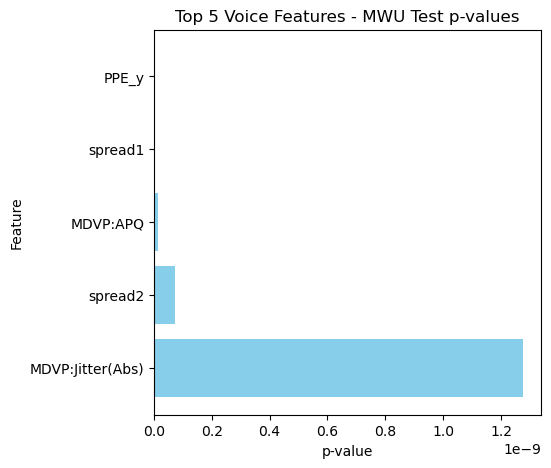

In [74]:
import matplotlib.pyplot as plt

# Sort MWU results by p-value and get top 15
top5_features = mwu_df.sort_values('p_value').head(5)

# Plot histogram of p-values
plt.figure(figsize=(5,5))
plt.barh(top5_features['Feature'], top5_features['p_value'], color='skyblue')
plt.xlabel('p-value')
plt.ylabel('Feature')
plt.title('Top 5 Voice Features - MWU Test p-values')
plt.gca().invert_yaxis()  # highest significance on top
plt.show()


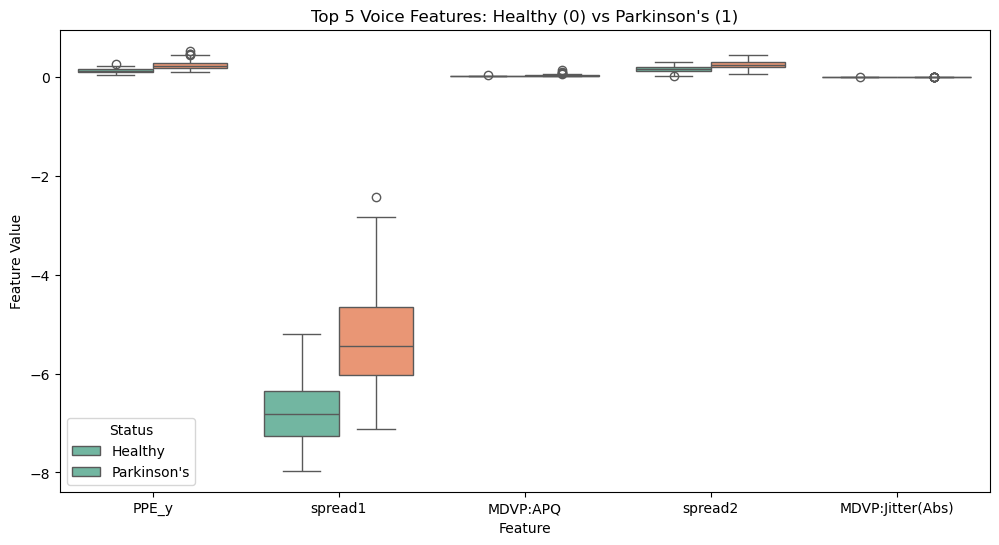

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Top 5 features based on MWU p-value
top5_features = mwu_df.sort_values('p_value').head(5)['Feature'].tolist()

# 2️⃣ Prepare data for plotting
plot_data = X_imputed[top5_features].copy()
plot_data['status'] = y.values  # add target

# 3️⃣ Melt dataframe for seaborn
plot_data_melted = plot_data.melt(id_vars='status', var_name='Feature', value_name='Value')

# 4️⃣ Plot grouped boxplots
plt.figure(figsize=(12,6))
sns.boxplot(x='Feature', y='Value', hue='status', data=plot_data_melted, palette='Set2')
plt.title('Top 5 Voice Features: Healthy (0) vs Parkinson\'s (1)')
plt.xlabel('Feature')
plt.ylabel('Feature Value')
plt.legend(title='Status', labels=['Healthy', 'Parkinson\'s'])
plt.show()


In [68]:
final_stats_table = (
    normality_df
    .merge(mwu_df, on="Feature")
)

final_stats_table


,Feature,Shapiro_W,p_value_x,Normal,MWU_statistic,p_value_y
0,DFA_x,0.758650,1.368890e-16,False,1713.0,9.046275e-08
1,MDVP:Fo(Hz),0.937053,1.733784e-07,False,2112.0,3.051504e-05
2,MDVP:Flo(Hz),0.860845,2.274372e-12,False,2136.0,4.151321e-05
3,MDVP:Shimmer,0.836068,1.487493e-13,False,5523.0,4.224740e-09
4,MDVP:APQ,0.762566,1.869091e-16,False,5827.5,1.269268e-11
5,HNR_y,0.972186,6.426216e-04,False,1849.0,7.641869e-07
6,spread1,0.984002,2.568415e-02,False,6329.0,1.592799e-16
7,spread2,0.994236,6.544443e-01,True,5741.0,7.159102e-11
8,PPE_y,0.956353,1.046718e-05,False,6329.0,1.592799e-16


In [83]:
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind
import numpy as np
from sklearn.impute import SimpleImputer

# 1️⃣ Prepare numeric features
numeric_features = df.select_dtypes(include='number').columns
numeric_features = numeric_features.drop(['sex', 'status'])

X_numeric = df[numeric_features].copy()

# 2️⃣ Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_numeric), columns=numeric_features)

# 3️⃣ Function: Cohen's d
def cohen_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    s_pooled = np.sqrt(((n1-1)*s1 + (n2-1)*s2)/(n1+n2-2))
    return (np.mean(x1) - np.mean(x2)) / s_pooled

# 4️⃣ Function: Rank-biserial correlation (non-parametric effect size for MWU)
def rank_biserial(x1, x2):
    U, _ = mannwhitneyu(x1, x2, alternative='two-sided')
    n1, n2 = len(x1), len(x2)
    return 1 - (2*U)/(n1*n2)

# 5️⃣ Run tests
results = []

for feature in numeric_features:
    group_pd = X_imputed.loc[y==1, feature]
    group_hc = X_imputed.loc[y==0, feature]
    
    # MWU test + rank-biserial
    stat_mwu, p_mwu = mannwhitneyu(group_pd, group_hc, alternative='two-sided')
    rbc = rank_biserial(group_pd, group_hc)
    
    # t-test + Cohen's d
    stat_t, p_t = ttest_ind(group_pd, group_hc, equal_var=False)
    d = cohen_d(group_pd, group_hc)
    
    results.append({
        'Feature': feature,
        'MWU_p_value': p_mwu,
        'MWU_RankBiserial': rbc,
        'T_p_value': p_t,
        'T_Cohen_d': d
    })

# 6️⃣ Create DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('MWU_p_value')
print(comparison_df)


             Feature   MWU_p_value  MWU_RankBiserial     T_p_value  T_Cohen_d
43             PPE_y  1.592799e-16         -0.793934  6.764318e-23   1.447377
40           spread1  1.592799e-16         -0.793934  1.769224e-21   1.580813
34          MDVP:APQ  1.269268e-11         -0.651786  3.367273e-16   0.903476
41           spread2  7.159102e-11         -0.627268  4.338049e-12   1.179528
26  MDVP:Jitter(Abs)  1.275739e-09         -0.577948  7.031183e-12   0.831234
28          MDVP:PPQ  2.401494e-09         -0.574405  5.548357e-10   0.696399
31  MDVP:Shimmer(dB)  3.143455e-09         -0.570153  1.877836e-14   0.864860
30      MDVP:Shimmer  4.224740e-09         -0.565476  1.063701e-15   0.912398
25    MDVP:Jitter(%)  7.897927e-09         -0.555414  1.238820e-08   0.668958
29      Jitter:DDP_y  8.180063e-09         -0.554847  1.307021e-08   0.638951
27          MDVP:RAP  8.689370e-09         -0.553855  1.301332e-08   0.639006
36             NHR_y  1.376242e-08         -0.546344  1.545708e-

C:\Users\Sara\AppData\Local\Temp\ipykernel_13876\714996162.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


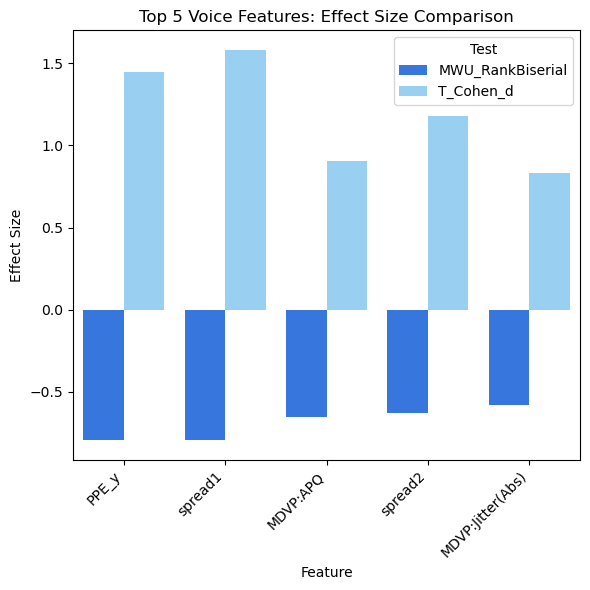

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 features based on MWU p-value
top5_features = comparison_df.sort_values('MWU_p_value').head(5)['Feature'].tolist()

# Prepare data for plotting
plot_data = comparison_df[comparison_df['Feature'].isin(top5_features)].copy()
plot_data = plot_data.melt(
    id_vars='Feature', 
    value_vars=['MWU_RankBiserial', 'T_Cohen_d'], 
    var_name='Test', 
    value_name='Effect_Size'
)

# Plot
plt.figure(figsize=(6,6))
sns.barplot(
    x='Feature',
    y='Effect_Size',
    hue='Test',
    data=plot_data,
    palette=["#1a70f9", "#8bd2ff"],
    ci=None
)

plt.title('Top 5 Voice Features: Effect Size Comparison')
plt.ylabel('Effect Size')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Test')  # ✅ NO manual labels
plt.tight_layout()
plt.show()

